<Axes: >

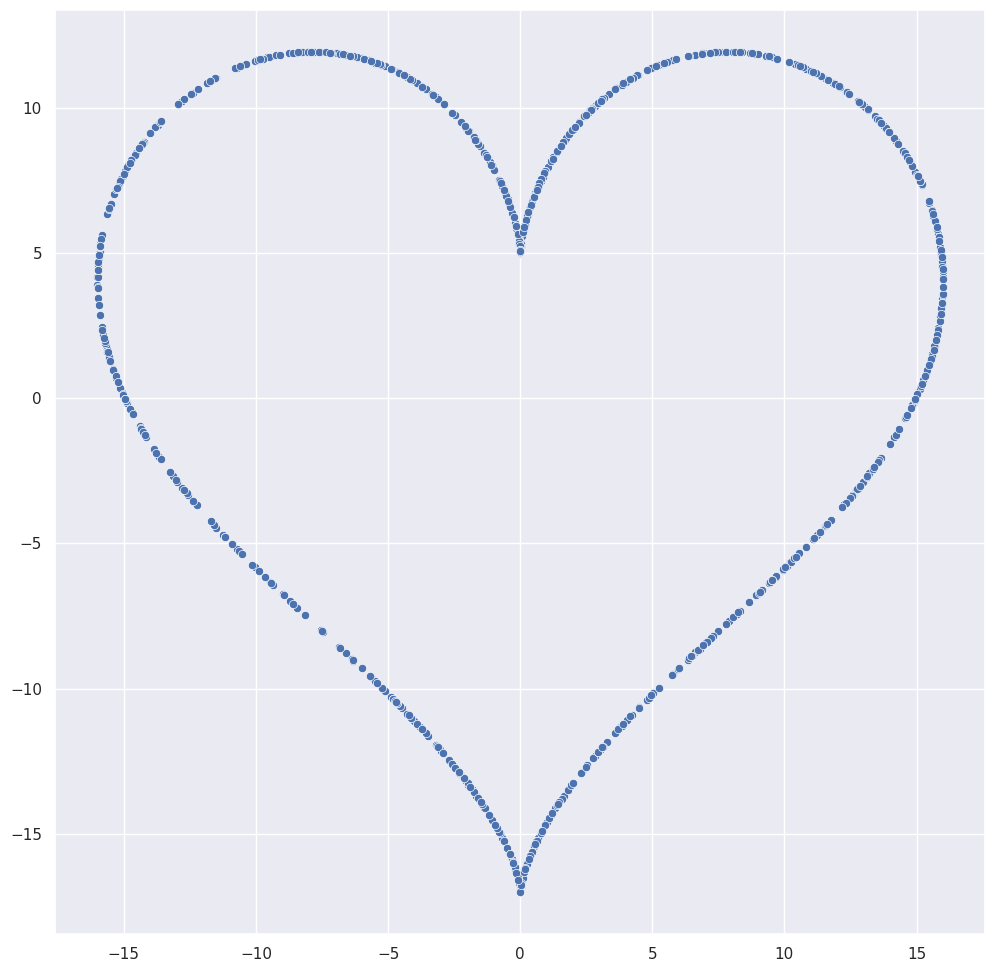

In [1]:
import torch
from torch.utils.data import DataLoader
from torch import nn

import math
import matplotlib.pyplot as plt
import numpy as np
from random import uniform

import seaborn as sns
sns.set(rc={'figure.figsize':(12,12)})
#%% create training data
TRAIN_DATA_COUNT = 1024
theta = np.array([uniform(0, 2 * np.pi) for _ in range(TRAIN_DATA_COUNT)])
# Generating x and y data
x = 16 * ( np.sin(theta) ** 3 )
y = 13 * np.cos(theta) - 5 * np.cos(2*theta) - 2 * np.cos(3*theta) - np.cos(4*theta)
sns.scatterplot(x=x, y=y)

In [2]:
#%% prepare tensors and dataloader
train_data = torch.Tensor(np.stack((x, y), axis=1))

train_labels = torch.zeros(TRAIN_DATA_COUNT)
train_set = [
    (train_data[i], train_labels[i]) for i in range(TRAIN_DATA_COUNT)
]

#  dataloader
BATCH_SIZE = 64
train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True
)

In [3]:
#%% initialize discriminator and generator
discriminator=nn.Sequential(
    nn.Linear(2, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128,64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64,1),
    nn.Sigmoid()
)

generator=nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16,64),
    nn.ReLU(),
    nn.Linear(64,2)
)


Epoch 500
Discriminator Loss: 0.49953457713127136
Generator Loss: 0.885526180267334


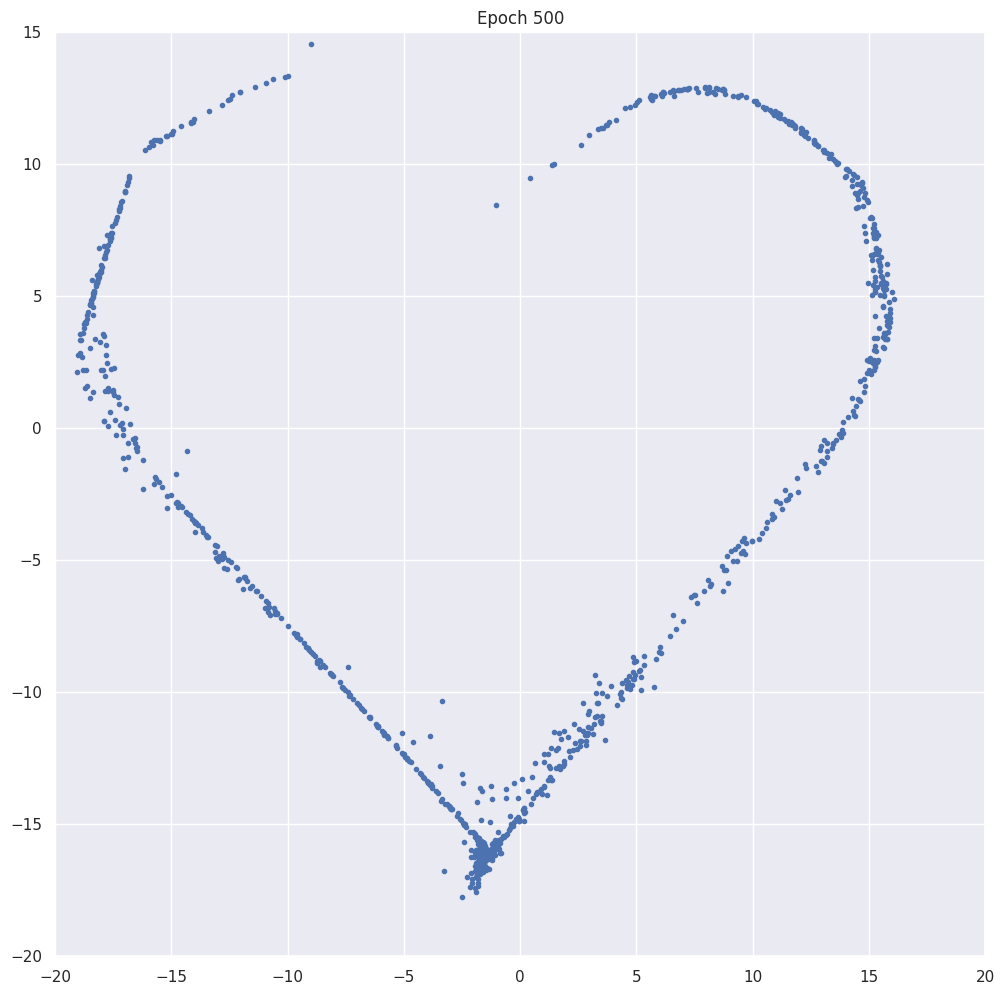


Epoch 1000
Discriminator Loss: 0.6286804676055908
Generator Loss: 0.8550792336463928


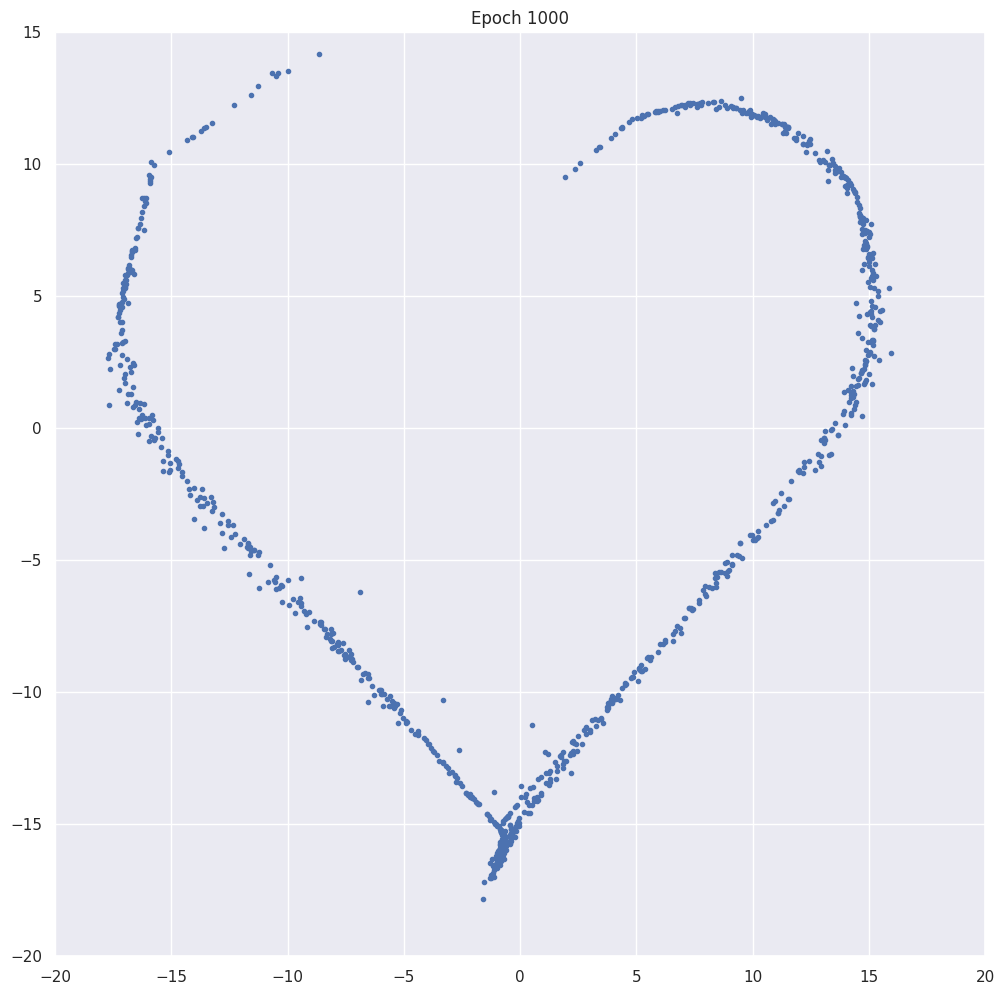


Epoch 1500
Discriminator Loss: 0.6141822338104248
Generator Loss: 0.9046002626419067


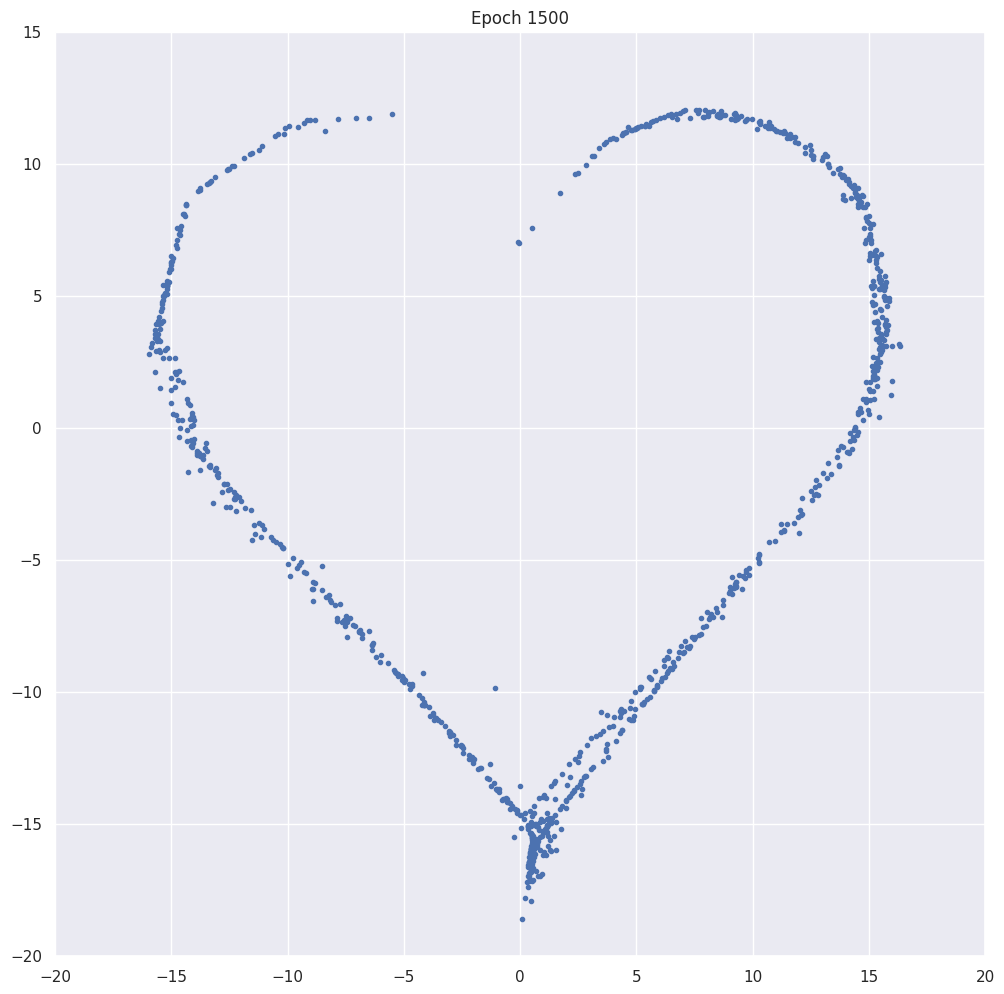


Epoch 2000
Discriminator Loss: 0.6374621391296387
Generator Loss: 0.8217030763626099


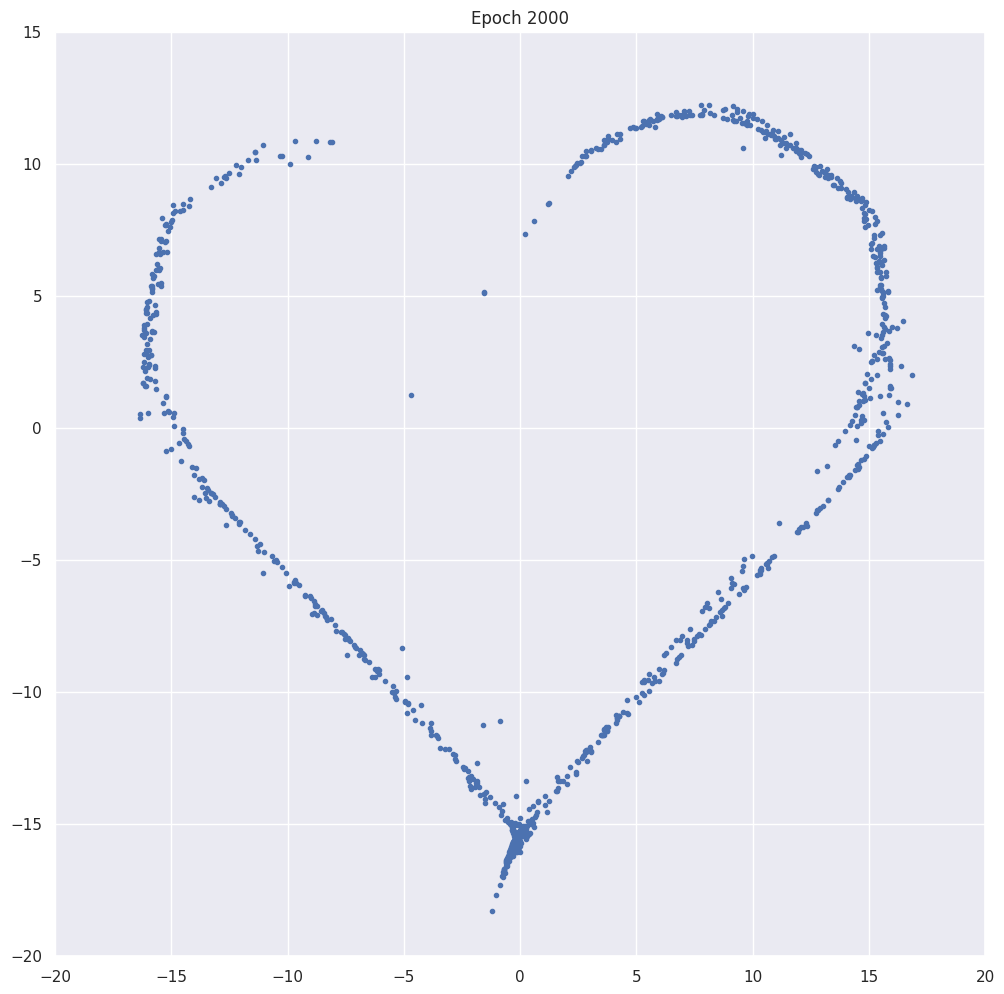


Epoch 2500
Discriminator Loss: 0.5297487378120422
Generator Loss: 0.9183669686317444


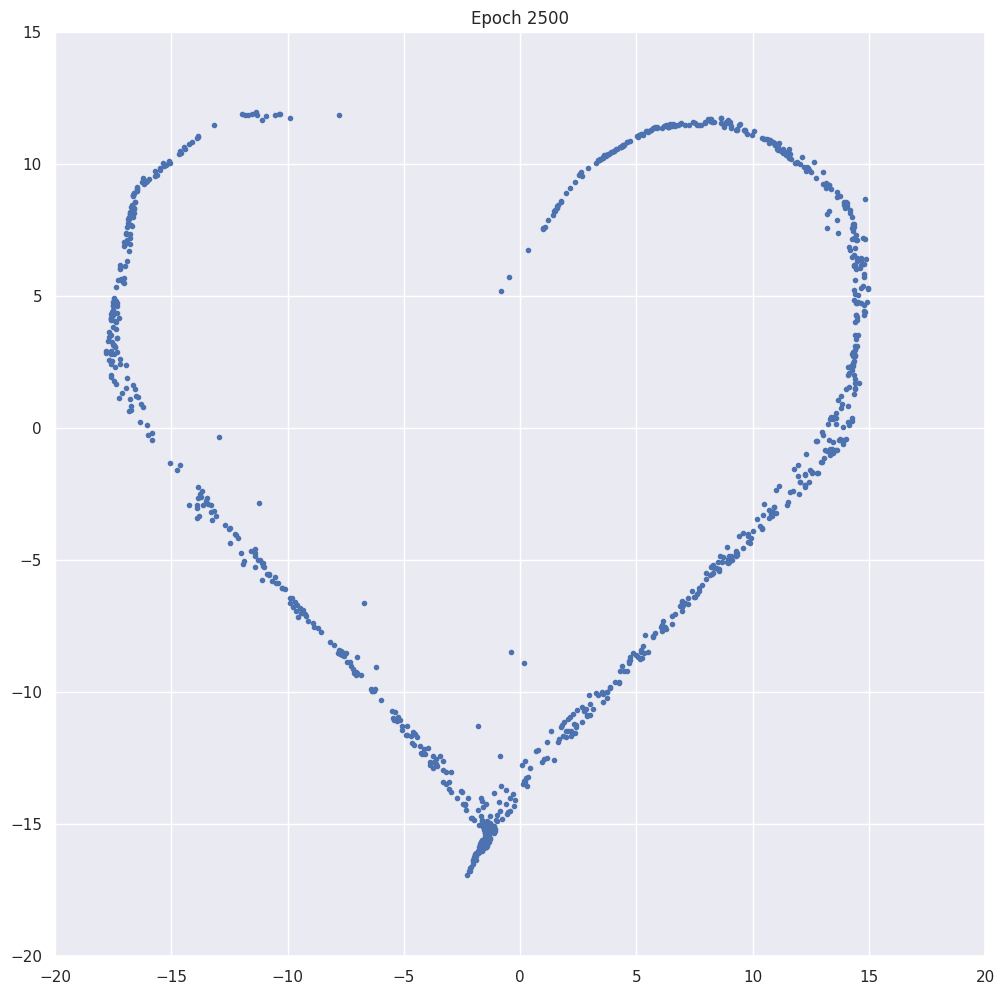


Epoch 3000
Discriminator Loss: 0.5420196056365967
Generator Loss: 0.8630167841911316


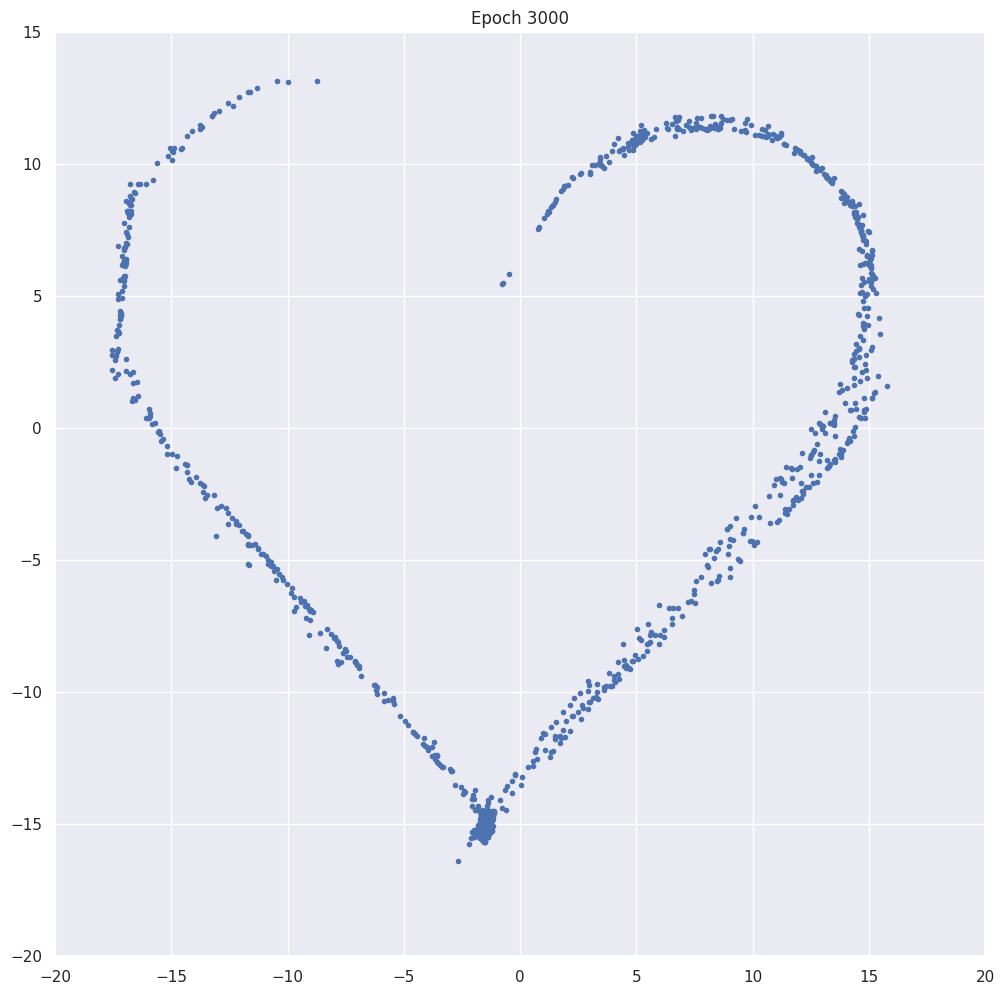


Epoch 3500
Discriminator Loss: 0.6180307269096375
Generator Loss: 0.8314159512519836


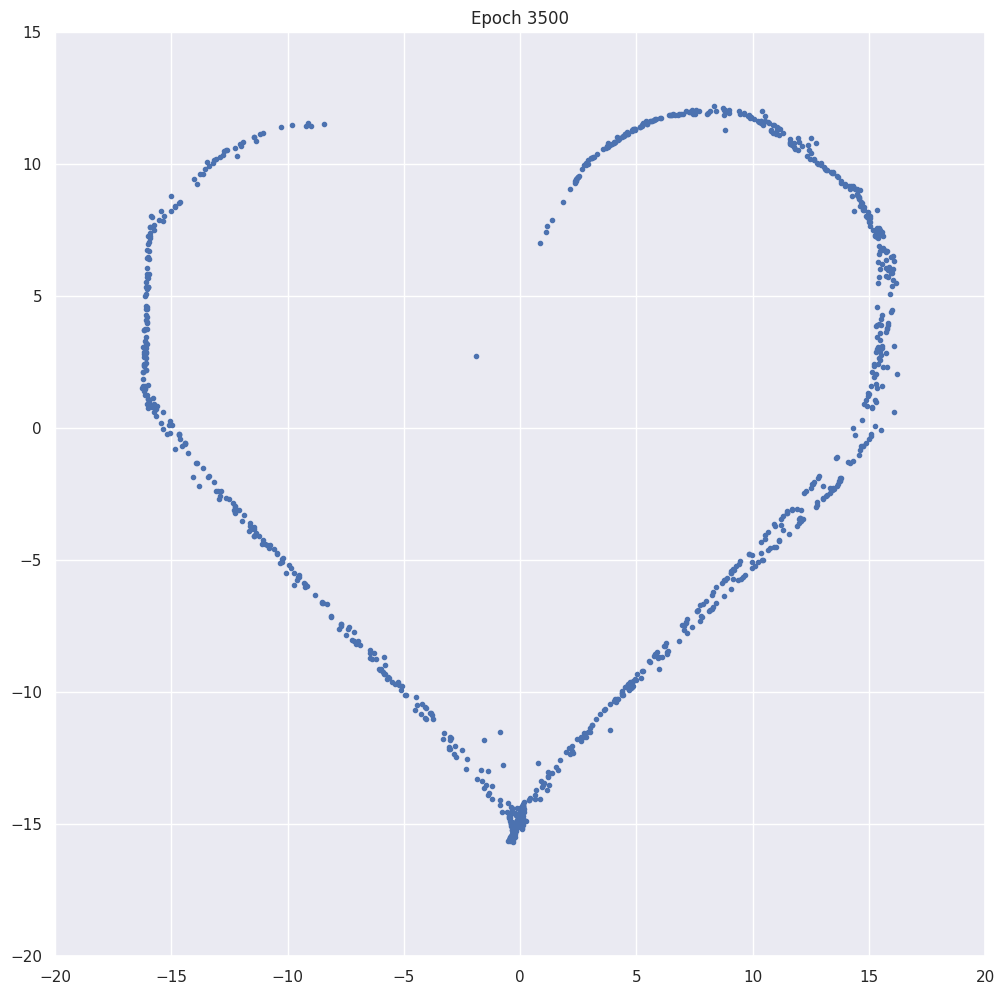

In [6]:
# %% training
LR = 0.001
NUM_EPOCHS = 4000
loss_function = nn.BCELoss()

optimizer_discriminator = torch.optim.Adam(discriminator.parameters())
optimizer_generator = torch.optim.Adam(generator.parameters())

for epoch in range(NUM_EPOCHS):
    for n, (real_samples, _) in enumerate(train_loader):

        # Data for training the discriminator
        real_samples_labels = torch.ones((BATCH_SIZE, 1))
        latent_space_samples = torch.randn((BATCH_SIZE, 2))
        generated_samples = generator(latent_space_samples)
        generated_samples_labels = torch.zeros((BATCH_SIZE, 1))

        all_samples = torch.cat((real_samples, generated_samples), dim=0)
        all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels), dim=0)

        # Train discriminator
        if epoch % 2 == 0:
            discriminator.zero_grad()
            output_discriminator = discriminator(all_samples)
            loss_discriminator = loss_function(output_discriminator, all_samples_labels)
            loss_discriminator.backward()
            optimizer_discriminator.step()

        # Train generator
        if epoch % 2 == 1:
            generator.zero_grad()
            latent_space_samples = torch.randn((BATCH_SIZE, 2))
            generated_samples = generator(latent_space_samples)
            output_discriminator_generator = discriminator(generated_samples)
            loss_generator = loss_function(output_discriminator_generator, real_samples_labels)
            loss_generator.backward()
            optimizer_generator.step()

    if epoch % 500 == 0 and epoch > 0:
        print(f"\nEpoch {epoch}")
        print(f"Discriminator Loss: {loss_discriminator}")
        print(f"Generator Loss: {loss_generator}")

        with torch.no_grad():
            latent_space_samples = torch.randn(1000, 2)
            generated_samples = generator(latent_space_samples).detach()

        plt.figure()
        plt.plot(generated_samples[:, 0], generated_samples[:, 1], ".")
        plt.xlim((-20, 20))
        plt.ylim((-20, 15))
        plt.title(f"Epoch {epoch}")
        plt.show()

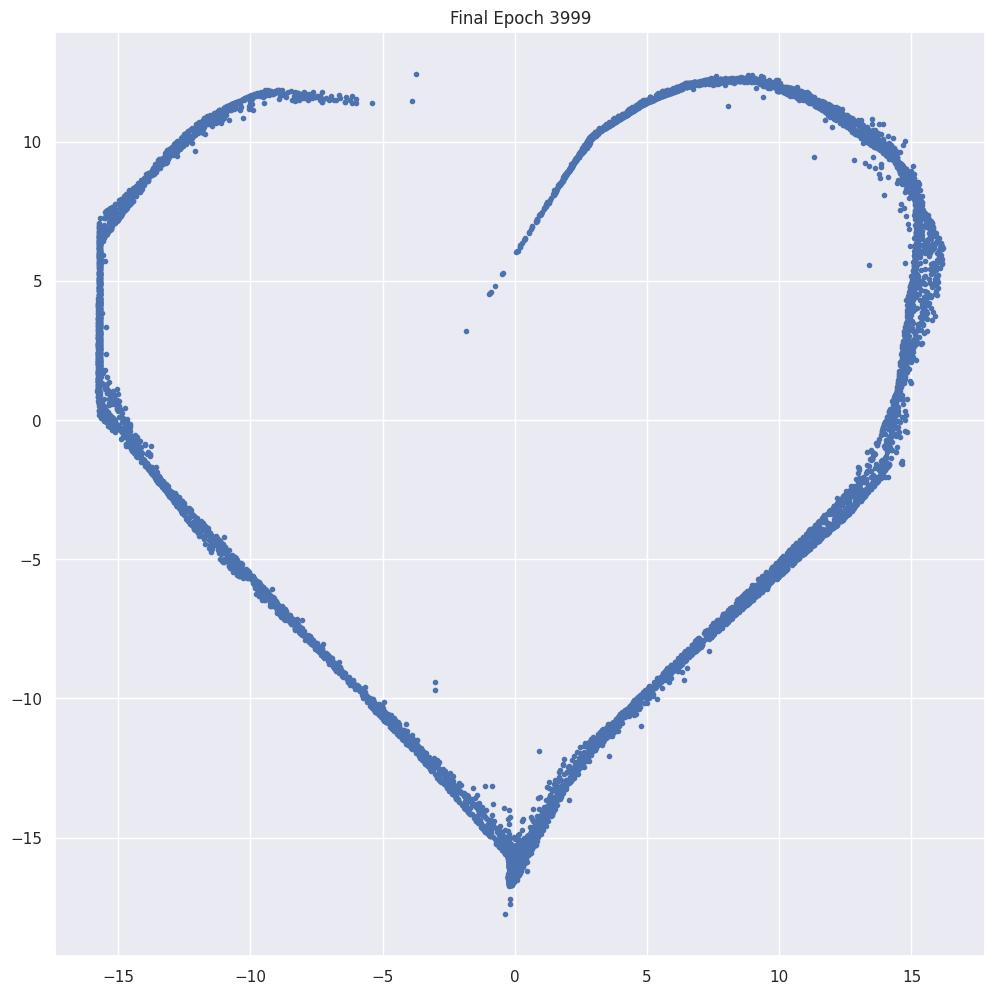

In [7]:
latent_space_samples = torch.randn(10000, 2)
generated_samples = generator(latent_space_samples).detach()

plt.figure()
plt.plot(generated_samples[:, 0], generated_samples[:, 1], ".")
plt.title(f"Final Epoch {epoch}")
plt.show()